In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn 
import torch.optim as optim

# scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [4]:
# load dataset
df = pd.read_csv('../dataset/insurance.csv')
df[:10]

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
5,31,female,25.740,0,no,southeast,3756.62160
6,46,female,33.440,1,no,southeast,8240.58960
7,37,female,27.740,3,no,northwest,7281.50560
8,37,male,29.830,2,no,northeast,6406.41070
9,60,female,25.840,0,no,northwest,28923.13692


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [6]:
df["sex"].unique()

array(['female', 'male'], dtype=object)

In [ ]:
custom_gender_map = {"male": 1, "female": 0}
df['sex'] = df['sex'].map(custom_gender_map)

In [ ]:
custom_smoker_map = {"yes": 1, "no": 0}
df['smoker'] = df['smoker'].map(custom_smoker_map)

In [ ]:
custom_region_map = {"southwest": 0, "southeast": 1, 'northwest': 2, "northeast": 3}
df['region'] = df['region'].map(custom_region_map)

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   int64  
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   int64  
 5   region    1338 non-null   int64  
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(5)
memory usage: 73.3 KB


In [15]:
df['charges'] = df['charges'].astype(int)

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   int64  
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   int64  
 5   region    1338 non-null   int64  
 6   charges   1338 non-null   int64  
dtypes: float64(1), int64(6)
memory usage: 73.3 KB


In [20]:
# Create X and y
X = df.drop('charges', axis=1)
y = df['charges']

In [ ]:
# Split dataset into train and test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [23]:
print(len(X_train))
print(len(y_train))
print(len(y_test))
print(len(X_test))

1070
1070
268
268


<Axes: >

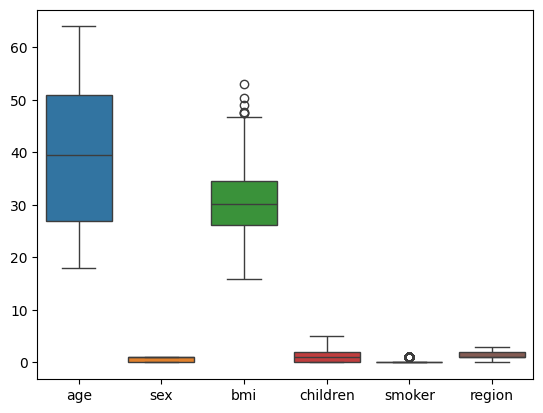

In [26]:
sns.boxplot(data=X_train)

In [29]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

<Axes: >

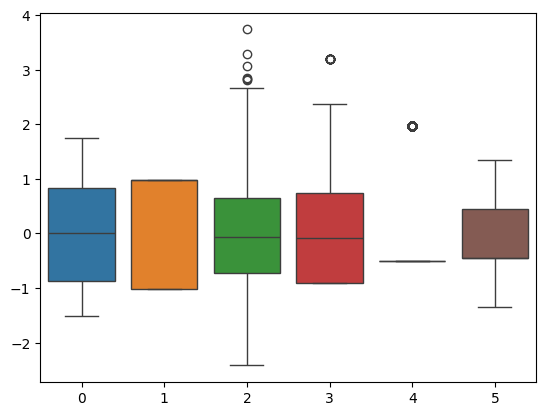

In [30]:
sns.boxplot(data=X_train_scaled)

In [40]:
# convert to tensors
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)


In [41]:
y_train_tensor

tensor([[ 9193.],
        [ 8534.],
        [27117.],
        ...,
        [11931.],
        [46113.],
        [10214.]])

In [46]:
X_train_tensor.shape, y_train_tensor.shape, X_test_tensor.shape, y_test_tensor.shape

(torch.Size([1070, 6]),
 torch.Size([1070, 1]),
 torch.Size([268, 6]),
 torch.Size([268, 1]))

In [48]:
# Make Neural Network model
class SimpleNNRegressionModel(nn.Module):
    def __init__(self, input_dim):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        return self.net(x)

In [51]:
X_train_tensor.shape

torch.Size([1070, 6])

In [52]:
X_train_tensor.shape[1]

6

In [53]:
input_dim = X_train_tensor.shape[1]
model = SimpleNNRegressionModel(input_dim)

In [54]:
model

SimpleNNRegressionModel(
  (net): Sequential(
    (0): Linear(in_features=6, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=1, bias=True)
  )
)

In [55]:
# Loss and Optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

In [56]:
optimizer

Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)

In [61]:
# training
epochs = 3000

for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    predictions = model(X_train_tensor)
    loss = criterion(predictions, y_train_tensor)
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 100 == 0:
        print(f"Epoch [{epoch + 1}]/{epochs} Loss: {loss.item() :.4f}")

Epoch [100]/3000 Loss: 12902224.0000
Epoch [200]/3000 Loss: 12808261.0000
Epoch [300]/3000 Loss: 12711745.0000
Epoch [400]/3000 Loss: 12621323.0000
Epoch [500]/3000 Loss: 12527355.0000
Epoch [600]/3000 Loss: 12435565.0000
Epoch [700]/3000 Loss: 12328160.0000
Epoch [800]/3000 Loss: 12224895.0000
Epoch [900]/3000 Loss: 12127841.0000
Epoch [1000]/3000 Loss: 12035819.0000
Epoch [1100]/3000 Loss: 11948588.0000
Epoch [1200]/3000 Loss: 11857928.0000
Epoch [1300]/3000 Loss: 11756519.0000
Epoch [1400]/3000 Loss: 11653039.0000
Epoch [1500]/3000 Loss: 11559002.0000
Epoch [1600]/3000 Loss: 11468789.0000
Epoch [1700]/3000 Loss: 11382427.0000
Epoch [1800]/3000 Loss: 11301269.0000
Epoch [1900]/3000 Loss: 11213095.0000
Epoch [2000]/3000 Loss: 11115392.0000
Epoch [2100]/3000 Loss: 11010876.0000
Epoch [2200]/3000 Loss: 10919969.0000
Epoch [2300]/3000 Loss: 10828268.0000
Epoch [2400]/3000 Loss: 10741757.0000
Epoch [2500]/3000 Loss: 10659094.0000
Epoch [2600]/3000 Loss: 10566183.0000
Epoch [2700]/3000 Los

In [74]:
# Model Evaluation

model.eval()
y_pred = model(X_test_tensor).detach().numpy()
y_test_numpy = y_test_tensor.numpy()


mse = mean_squared_error(y_test_numpy, y_pred)
mae = mean_absolute_error(y_test_numpy, y_pred)
score = r2_score(y_test_numpy, y_pred)

print(f"Mean Squared Error {mse:.2f}")
print(f"Mean Absolute Error {mae:.2f}")
print(f"R2 Score {score:.2f} %")

Mean Squared Error 28335872.00
Mean Absolute Error 3355.10
R2 Score 0.82 %


In [76]:
df[:10]

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,0,16884
1,18,1,33.770,1,0,1,1725
2,28,1,33.000,3,0,1,4449
3,33,1,22.705,0,0,2,21984
4,32,1,28.880,0,0,2,3866
5,31,0,25.740,0,0,1,3756
6,46,0,33.440,1,0,1,8240
7,37,0,27.740,3,0,2,7281
8,37,1,29.830,2,0,3,6406
9,60,0,25.840,0,0,2,28923


In [91]:
def predict_charges(age, sex, bim, children, smoker, region):
    input_data = pd.DataFrame([[ age, sex, bim, children, smoker, region ]], 
                              columns=['age', 'sex', 'bim', 'children', 'smoker', 'region'])
    
    # Map categorical values to numbers
    custom_gender_map = {"male": 1, "female": 0}
    input_data['sex'] = input_data['sex'].map(custom_gender_map)
    custom_smoker_map = {"yes": 1, "no": 0}
    input_data['smoker'] = input_data['smoker'].map(custom_smoker_map)
    custom_region_map = {"southwest": 0, "southeast": 1, 'northwest': 2, "northeast": 3}
    input_data['region'] = input_data['region'].map(custom_region_map)

     # Get prediction
    input_tensor = torch.tensor(input_data.values, dtype=torch.float32)
    predict_charge = model(input_tensor).item()
    return predict_charge
 

In [97]:
predicted = predict_charges(25, "male", 33.000 , 3, "no", "southwest")

In [98]:
print(f"Predicted insurance charge: ${predicted:.2f}")

Predicted insurance charge: $218212.89


In [ ]:
# Evaluation
model.eval()

with torch.no_grad(): # stop gradient
    outputs = model(X_test_tensor)
    predicted = torch.argmax(outputs, dim=1)
    print(predicted)
    correct = (predicted == y_test_tensor).sum().item()
    print("Correct --> ", correct)
    total = len(y_test_tensor)
    print("Total --> ", total)
    accuracy = correct / total
    print(f"Evaluation accuracy: {accuracy*100:.2f}%")

### All Code

In [99]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn 
import torch.optim as optim

# scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# load dataset
df = pd.read_csv('../dataset/insurance.csv')

# Categorical value into numerical value
custom_gender_map = {"male": 1, "female": 0}
df['sex'] = df['sex'].map(custom_gender_map)

custom_region_map = {"southwest": 0, "southeast": 1, 'northwest': 2, "northeast": 3}
df['region'] = df['region'].map(custom_region_map)

custom_smoker_map = {"yes": 1, "no": 0}
df['smoker'] = df['smoker'].map(custom_smoker_map)

# Create X and y
X = df.drop('charges', axis=1)
y = df['charges']

# Split dataset into train and test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Normalization
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# convert to tensors
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

# Make Neural Network model
class SimpleNNRegressionModel(nn.Module):
    def __init__(self, input_dim):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        return self.net(x)
    
input_dim = X_train_tensor.shape[1]
model = SimpleNNRegressionModel(input_dim)


# Loss and Optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# training
epochs = 3000

for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    predictions = model(X_train_tensor)
    loss = criterion(predictions, y_train_tensor)
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 100 == 0:
        print(f"Epoch [{epoch + 1}]/{epochs} Loss: {loss.item() :.4f}")


# Model Evaluation
model.eval()
y_pred = model(X_test_tensor).detach().numpy()
y_test_numpy = y_test_tensor.numpy()

mse = mean_squared_error(y_test_numpy, y_pred)
mae = mean_absolute_error(y_test_numpy, y_pred)
score = r2_score(y_test_numpy, y_pred)

print(f"Mean Squared Error {mse:.2f}")
print(f"Mean Absolute Error {mae:.2f}")
print(f"R2 Score {score:.2f} %")

Epoch [100]/3000 Loss: 321067104.0000
Epoch [200]/3000 Loss: 309998080.0000
Epoch [300]/3000 Loss: 276726080.0000
Epoch [400]/3000 Loss: 216630816.0000
Epoch [500]/3000 Loss: 143256336.0000
Epoch [600]/3000 Loss: 84006272.0000
Epoch [700]/3000 Loss: 53945776.0000
Epoch [800]/3000 Loss: 42625472.0000
Epoch [900]/3000 Loss: 37831636.0000
Epoch [1000]/3000 Loss: 35343404.0000
Epoch [1100]/3000 Loss: 33944248.0000
Epoch [1200]/3000 Loss: 33055172.0000
Epoch [1300]/3000 Loss: 32378696.0000
Epoch [1400]/3000 Loss: 31761514.0000
Epoch [1500]/3000 Loss: 31123290.0000
Epoch [1600]/3000 Loss: 30412210.0000
Epoch [1700]/3000 Loss: 29615624.0000
Epoch [1800]/3000 Loss: 28730568.0000
Epoch [1900]/3000 Loss: 27798558.0000
Epoch [2000]/3000 Loss: 26858296.0000
Epoch [2100]/3000 Loss: 25964532.0000
Epoch [2200]/3000 Loss: 25137844.0000
Epoch [2300]/3000 Loss: 24411490.0000
Epoch [2400]/3000 Loss: 23777524.0000
Epoch [2500]/3000 Loss: 23225380.0000
Epoch [2600]/3000 Loss: 22754916.0000
Epoch [2700]/300